In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
import numpy as np
X = 2 * np.random.rand(100, 1)
noise = np.random.randn(100, 1)
y = 4 + 3 * X + noise

In [4]:
print(X.shape)
print(y.shape)

print(X[:5])
print(y[:5])

(100, 1)
(100, 1)
[[0.02471864]
 [0.89735764]
 [0.17963327]
 [0.96545338]
 [0.74154584]]
[[1.87152074]
 [6.13659617]
 [4.13875923]
 [8.19422032]
 [5.42116877]]


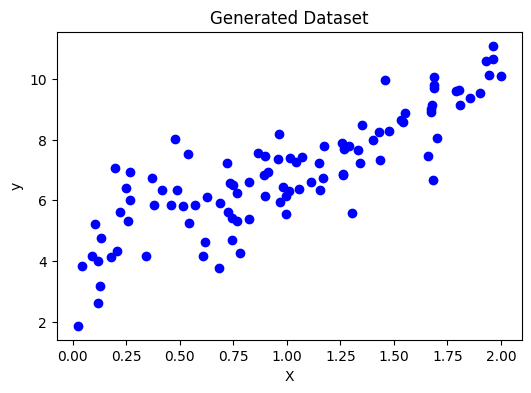

In [5]:
plt.figure(figsize=(6,4))
plt.scatter(X, y, color='blue')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Dataset")
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(80, 1)
(20, 1)


In [7]:
class LinearRegressionGD:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.losses = []

    def fit(self, X, y):

        m = len(X)

        self.weight = 0
        self.bias = 0

        for epoch in range(self.epochs):

            y_pred = self.weight * X + self.bias

            dw = (-2/m) * np.sum(X * (y - y_pred))
            db = (-2/m) * np.sum(y - y_pred)

            self.weight -= self.lr * dw
            self.bias -= self.lr * db

            loss = np.mean((y - y_pred) ** 2)
            self.losses.append(loss)

    def predict(self, X):
        return self.weight * X + self.bias

In [8]:
model = LinearRegressionGD(
    learning_rate=0.01,
    epochs=1000
)

model.fit(X_train, y_train)
print("Weight :", model.weight)
print("Bias :", model.bias)
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

Weight : 2.9724257455110648
Bias : 3.960045244260186


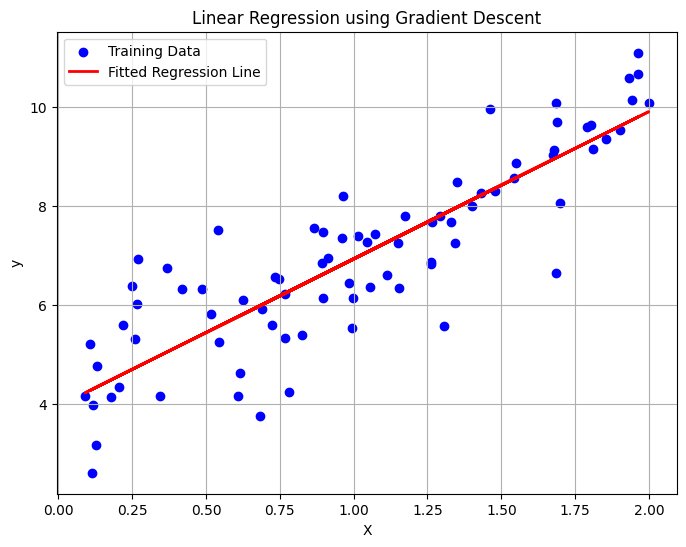

In [9]:
# Predictions on training data
y_pred_train = model.predict(X_train)

# Plot the training data
plt.figure(figsize=(8,6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Plot the fitted regression line
plt.plot(X_train, y_pred_train, color='red', linewidth=2, label='Fitted Regression Line')

plt.title("Linear Regression using Gradient Descent")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
learning_rates = [0.001, 0.01, 0.1]
epochs_list = [500, 1000, 2000]
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return mae, mse, rmse, r2
results = []

for lr in learning_rates:

    for epoch in epochs_list:

        model = LinearRegressionGD(
            learning_rate=lr,
            epochs=epoch
        )

        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_mae, train_mse, train_rmse, train_r2 = evaluate(y_train, train_pred)
        test_mae, test_mse, test_rmse, test_r2 = evaluate(y_test, test_pred)

        results.append({
            "Learning Rate": lr,
            "Epochs": epoch,
            "Train MAE": train_mae,
            "Train MSE": train_mse,
            "Train RMSE": train_rmse,
            "Train R²": train_r2,
            "Test MAE": test_mae,
            "Test MSE": test_mse,
            "Test RMSE": test_rmse,
            "Test R²": test_r2
        })
results_df = pd.DataFrame(results)

results_df


,Learning Rate,Epochs,Train MAE,Train MSE,Train RMSE,Train R²,Test MAE,Test MSE,Test RMSE,Test R²
0,0.001,500,1.079139,1.688635,1.299475,0.530925,1.133538,2.251097,1.500366,0.279868
1,0.001,1000,0.768647,1.022726,1.011299,0.715903,0.983270,1.638298,1.279960,0.475904
2,0.001,2000,0.746497,0.967404,0.983567,0.731271,0.956828,1.552323,1.245923,0.503408
3,0.010,500,0.729368,0.917233,0.957723,0.745207,0.922256,1.447821,1.203254,0.536838
4,0.010,1000,0.731348,0.906987,0.952359,0.748054,0.913037,1.408523,1.186812,0.549410
5,0.010,2000,0.733055,0.906377,0.952038,0.748223,0.911204,1.399534,1.183019,0.552285
6,0.100,500,0.733157,0.906375,0.952037,0.748224,0.911160,1.399034,1.182808,0.552446
7,0.100,1000,0.733157,0.906375,0.952037,0.748224,0.911160,1.399034,1.182807,0.552446
8,0.100,2000,0.733157,0.906375,0.952037,0.748224,0.911160,1.399034,1.182807,0.552446


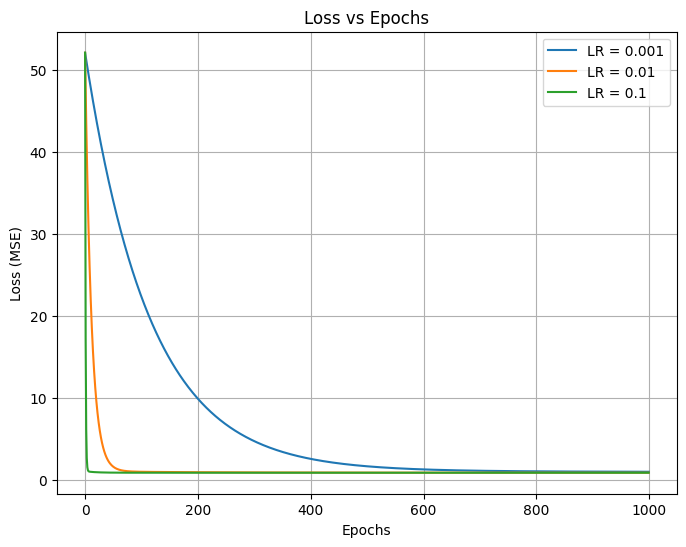

In [14]:
plt.figure(figsize=(8,6))
for lr in learning_rates:
    model = LinearRegressionGD(
        learning_rate=lr,
        epochs=1000
    )
    model.fit(X_train, y_train)
    plt.plot(model.losses, label=f"LR = {lr}")
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
best_model = LinearRegressionGD(
    learning_rate=0.01,
    epochs=1000
)
best_model.fit(X_train, y_train)
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

In [16]:
train_mae, train_mse, train_rmse, train_r2 = evaluate(
    y_train,
    train_pred
)
print("Training Performance")
print(f"MAE  : {train_mae:.4f}")
print(f"MSE  : {train_mse:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")

Training Performance
MAE  : 0.7313
MSE  : 0.9070
RMSE : 0.9524
R²   : 0.7481


In [17]:
test_mae, test_mse, test_rmse, test_r2 = evaluate(
    y_test,
    test_pred
)
print("\nTesting Performance")
print(f"MAE  : {test_mae:.4f}")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")


Testing Performance
MAE  : 0.9130
MSE  : 1.4085
RMSE : 1.1868
R²   : 0.5494


The loss decreased steadily with each epoch, which shows that Gradient Descent converged successfully.
A learning rate of 0.001 learned slowly and needed more epochs, while 0.01 and 0.1 converged much faster.
The training metrics (MAE = 0.7313, RMSE = 0.9524, R² = 0.7481) were better than the testing metrics (MAE = 0.9130, RMSE = 1.1868, R² = 0.5494), which is expected.
The gap between training and testing performance is mainly due to the random noise added while generating the dataset.
Overall, the model learned the linear relationship well and gave reasonable predictions on both the training and testing data.

Conclusion-
The Linear Regression model implemented using Gradient Descent worked as expected. The model converged properly, and the evaluation metrics showed that it was able to capture the underlying trend in the data with good accuracy.